In [1]:
! pip install pandas matplotlib numpy tensorflow scikit-learn
! pip install nvidia-cudnn-cu12==9.3.0.75

In [1]:
# Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Bidirectional, LSTM, Dense, Dropout,
    BatchNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Input, Add, LayerNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from boxe_utils import *

os.chdir("/lapix/privado/boxe.ml")

I0000 00:00:1780624155.783855 1644678 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780624155.851711 1644678 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780624157.624978 1644678 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
TRAIN_VIDEOS = ["V1", "V2", "V4", "V5", "V7"]  # laterais, sem V3
VAL_VIDEOS   = ["V3"]                          # lateral nunca visto
TEST_VIDEOS  = ["V9"]                          # frontal nunca visto

X_tr_raw, y_tr_raw = [], []
for video in TRAIN_VIDEOS:
    skeleton, labels = load_video(video)
    X_tr_raw.append(skeleton)
    y_tr_raw.append(labels)
X_tr_raw = np.concatenate(X_tr_raw)
y_tr_raw = np.concatenate(y_tr_raw)

X_val_raw, y_val_raw = [], []
for video in VAL_VIDEOS:
    skeleton, labels = load_video(video)
    X_val_raw.append(skeleton)
    y_val_raw.append(labels)
X_val_raw = np.concatenate(X_val_raw)
y_val_raw = np.concatenate(y_val_raw)

X_te_raw, y_te_raw = [], []
for video in TEST_VIDEOS:
    skeleton, labels = load_video(video)
    X_te_raw.append(skeleton)
    y_te_raw.append(labels)
X_te_raw = np.concatenate(X_te_raw)
y_te_raw = np.concatenate(y_te_raw)

print("Shape total treino:", X_tr_raw.shape)
print("Shape total validação:", X_val_raw.shape)
print("Shape total teste:", X_te_raw.shape)

print("Total amostras treino:", len(y_tr_raw))
print("Total amostras teste:", len(y_te_raw))
print("Total amostras validação:", len(y_val_raw))

Shape total treino: (3451, 25, 17, 2)
Shape total validação: (815, 25, 17, 2)
Shape total teste: (149, 25, 17, 2)
Total amostras treino: 3451
Total amostras teste: 149
Total amostras validação: 815


In [5]:
classes, label_to_id, id_to_label = build_label_mapping(y_tr_raw)
y_tr = np.array([label_to_id[x] for x in y_tr_raw])
y_val = np.array([label_to_id[x] for x in y_val_raw])
y_te = np.array([label_to_id[x] for x in y_te_raw])

num_classes = len(classes)

print("Classes:", classes)
print("Distribuição treino:")
unique, counts = np.unique(y_tr, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")
    
print("Distribuição validação:")
unique, counts = np.unique(y_val, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")
    
print("Distribuição teste:")
unique, counts = np.unique(y_te, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")

Classes: [np.str_('Cross'), np.str_('Jab'), np.str_('Lead Hook'), np.str_('Lead Uppercut'), np.str_('Rear Hook'), np.str_('Rear Uppercut')]
Distribuição treino:
  Cross: 922
  Jab: 867
  Lead Hook: 693
  Lead Uppercut: 347
  Rear Hook: 248
  Rear Uppercut: 374
Distribuição validação:
  Cross: 354
  Jab: 315
  Lead Hook: 83
  Lead Uppercut: 17
  Rear Hook: 32
  Rear Uppercut: 14
Distribuição teste:
  Cross: 27
  Jab: 31
  Lead Hook: 20
  Lead Uppercut: 25
  Rear Hook: 11
  Rear Uppercut: 35


In [6]:
X_tr  = X_tr_raw.reshape(X_tr_raw.shape[0], 25, 34)
X_val = X_val_raw.reshape(X_val_raw.shape[0], 25, 34)
X_te  = X_te_raw.reshape(X_te_raw.shape[0], 25, 34)

print("Shape após reshape treino:", X_tr.shape)
print("Shape após reshape validação:", X_val.shape)
print("Shape após reshape teste:", X_te.shape)

Shape após reshape treino: (3451, 25, 34)
Shape após reshape validação: (815, 25, 34)
Shape após reshape teste: (149, 25, 34)


In [7]:
# Normalização global (fit só no treino, aplica em ambos)
X_mean_global = X_tr.mean()
X_std_global  = X_tr.std() + 1e-8

X_val = X_val_raw.reshape(X_val_raw.shape[0], 25, 34)
X_val_norm = (X_val - X_mean_global) / X_std_global

X_tr_norm = (X_tr - X_mean_global) / X_std_global
X_te_norm = (X_te - X_mean_global) / X_std_global

print("Valor da Média:", X_mean_global)
print("Valor do Desvio:", X_std_global)
print("Normalização aplicada")
print(f"  Treino — min: {X_tr_norm.min():.3f}, max: {X_tr_norm.max():.3f}")
print(f"  Teste  — min: {X_te_norm.min():.3f}, max: {X_te_norm.max():.3f}")

Valor da Média: 0.1763427519365391
Valor do Desvio: 0.24370889809812205
Normalização aplicada
  Treino — min: -0.724, max: 3.338
  Teste  — min: -0.724, max: 2.991


In [8]:
# Adicionar velocidade e aceleração
# X shape: (N, 25, 34) → saída: (N, 25, 102)
# Os 34 features originais são posição dos keypoints
# Velocidade = diferença entre frames consecutivos (como o soco se move)
# Aceleração = diferença da velocidade (quão rápido muda a direção)
# Isso ajuda a distinguir Cross de Jab, que têm trajetórias parecidas mas velocidades diferentes

X_val_feat = add_velocity_and_acceleration(X_val_norm)
X_tr_feat = add_velocity_and_acceleration(X_tr_norm)
X_te_feat = add_velocity_and_acceleration(X_te_norm)

print("Shape com velocidade e aceleração:", X_tr_feat.shape)

Shape com velocidade e aceleração: (3451, 25, 102)


In [10]:
def augment_skeleton(X, y, noise_std=0.02):
    X_aug = X.copy()
    y_aug = y.copy()
    
    # Ruído gaussiano — sempre válido
    X_aug += np.random.normal(0, noise_std, X_aug.shape)
    
    # Escala temporal — estica ou comprime a velocidade do golpe
    scale = np.random.uniform(0.8, 1.2)
    X_aug = X_aug * scale
    
    return X_aug, y_aug

X_tr_aug1, y_tr_aug1 = augment_skeleton(X_tr_feat, y_tr, noise_std=0.02)
X_tr_aug2, y_tr_aug2 = augment_skeleton(X_tr_feat, y_tr, noise_std=0.04)
X_tr_aug3, y_tr_aug3 = augment_skeleton(X_tr_feat, y_tr, noise_std=0.01)
X_tr_final = np.concatenate([X_tr_feat, X_tr_aug1, X_tr_aug2, X_tr_aug3])
y_tr_final = np.concatenate([y_tr, y_tr_aug1, y_tr_aug2, y_tr_aug3])

print("Treino com augmentation:", X_tr_final.shape)

Treino com augmentation: (13804, 25, 102)


In [11]:
# Construir modelo
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    attn = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)

model = build_model(input_shape=(25, 102), num_classes=num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1780624352.184208 1644678 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 71688 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:1b:00.0, compute capability: 9.0a
I0000 00:00:1780624352.192822 1644678 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 36565 MB memory:  -> device: 1, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:43:00.0, compute capability: 9.0a
I0000 00:00:1780624353.084502 1644678 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 53603 MB memory:  -> device: 2, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:52:00.0, compute capability: 9.0a
I0000 00:00:1780624353.187637 1644678 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43191 MB memory:  -> device: 3, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:61:00.0, compute capability: 9.0a
I0000 00:00:1780624353.238236 1644678 gpu_device.cc:2043] Cr

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 25, 102)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 25, 256)   │    236,544 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 25, 256)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 25, 128)   │    164,352 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 25, 128)   │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 25, 128)   │     66,048 │ dropout_1[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 25, 128)   │          0 │ dropout_1[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 25, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6)         │        774 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 484,998 (1.85 MB)

 Trainable params: 484,742 (1.85 MB)

 Non-trainable params: 256 (1.00 KB)

In [12]:
# Class weights e callbacks
weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=y_tr_final)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        mode="max"
    ),
    ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        mode="max",
        verbose=1
    ),
    ModelCheckpoint(
        "best_model_v2.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

Class weights: {0: np.float64(0.6238250180766449), 1: np.float64(0.6633986928104575), 2: np.float64(0.82996632996633), 3: np.float64(1.6575408261287223), 4: np.float64(2.319220430107527), 5: np.float64(1.5378787878787878)}


In [13]:
# Treinar
history = model.fit(
    X_tr_final, y_tr_final,
    validation_data=(X_val_feat, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


I0000 00:00:1780624567.425340 1645439 cuda_dnn.cc:461] Loaded cuDNN version 90300


432/432 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3615 - loss: 1.6891
Epoch 1: val_accuracy improved from None to 0.10061, saving model to best_model_v2.keras

Epoch 1: finished saving model to best_model_v2.keras
432/432 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.4900 - loss: 1.3686 - val_accuracy: 0.1006 - val_loss: 3.7453 - learning_rate: 0.0010
Epoch 2/100
430/432 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7144 - loss: 0.8049
Epoch 2: val_accuracy improved from 0.10061 to 0.20982, saving model to best_model_v2.keras

Epoch 2: finished saving model to best_model_v2.keras
432/432 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7341 - loss: 0.7481 - val_accuracy: 0.2098 - val_loss: 2.4066 - learning_rate: 0.0010
Epoch 3/100
430/432 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8001 - loss: 0.5617
Epoch 3: val_accuracy improved from 0.20982 to 0.22577, saving model to best_model_v2.keras

Epoch 3: finished saving model to best_model_v2.keras
432/432 ━━━━━━━━━━━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 283ms/step
               precision    recall  f1-score   support

        Cross       0.64      1.00      0.78        27
          Jab       0.84      1.00      0.91        31
    Lead Hook       0.81      0.65      0.72        20
Lead Uppercut       0.96      0.88      0.92        25
    Rear Hook       0.00      0.00      0.00        11
Rear Uppercut       1.00      0.86      0.92        35

     accuracy                           0.83       149
    macro avg       0.71      0.73      0.71       149
 weighted avg       0.80      0.83      0.80       149



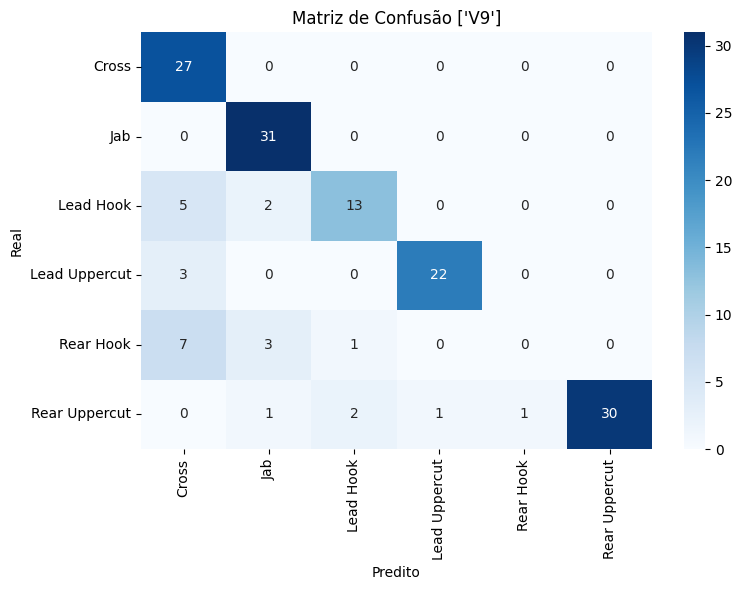

In [18]:
# Avaliar
from tensorflow.keras.models import load_model

best_model = load_model("best_model_v2.keras")
y_pred = np.argmax(best_model.predict(X_te_feat), axis=1)

print(classification_report(y_te, y_pred, target_names=classes))

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.title(f'Matriz de Confusão {TEST_VIDEOS}')
plt.tight_layout()
plt.savefig("matrix.png")
plt.show()

In [15]:
model.save('modelo_boxe.keras')